In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
# nge load data
df_all = pd.read_csv('all.csv', sep='|', on_bad_lines='skip') 
df_mean = pd.read_csv('job_salary_mean.csv')
df_region = pd.read_csv('Indonesian Salary by Region (1997-2025).csv')

# untuk data cleaning
df_model = df_all.dropna(subset=['salary', 'experience_level', 'location', 'job_title']).copy()

def parse_experience(exp):
    try:
        if pd.isna(exp): return 0
        exp_str = str(exp).lower()
        if 'kurang' in exp_str or 'less' in exp_str: return 0
        nums = re.findall(r'\d+', exp_str)
        return int(nums[0]) if nums else 0
    except:
        return 0

df_model['pengalamanKerja'] = df_model['experience_level'].apply(parse_experience)

In [3]:
mean_salary_df = df_mean.groupby(['Judul Pekerjaan', 'Lokasi'])['Gaji_Rata2'].mean().reset_index()
mean_salary_df.rename(columns={'Judul Pekerjaan': 'job_title', 'Lokasi': 'location', 'Gaji_Rata2': 'rata2Gaji'}, inplace=True)

df_model = pd.merge(df_model, mean_salary_df, on=['job_title', 'location'], how='left')
df_model['rata2Gaji'] = df_model['rata2Gaji'].fillna(df_model['salary'].median()) 

In [4]:
provinsi = {
    'Jakarta Raya': 'DKI JAKARTA', 'Jakarta Pusat': 'DKI JAKARTA', 'Jakarta Selatan': 'DKI JAKARTA', 
    'Jakarta Timur': 'DKI JAKARTA', 'Jakarta Utara': 'DKI JAKARTA', 'Jakarta Barat': 'DKI JAKARTA',
    'Bandung': 'JAWA BARAT', 'Bekasi': 'JAWA BARAT', 'Bogor': 'JAWA BARAT', 'Depok': 'JAWA BARAT',
    'Cirebon': 'JAWA BARAT', 'Sukabumi': 'JAWA BARAT', 'Cikarang': 'JAWA BARAT', 'Karawang': 'JAWA BARAT',
    'Semarang': 'JAWA TENGAH', 'Surakarta': 'JAWA TENGAH', 'Solo': 'JAWA TENGAH', 'Tegal': 'JAWA TENGAH', 
    'Surabaya': 'JAWA TIMUR', 'Malang': 'JAWA TIMUR', 'Sidoarjo': 'JAWA TIMUR', 'Gresik': 'JAWA TIMUR',
    'Yogyakarta': 'DI YOGYAKARTA', 'Sleman': 'DI YOGYAKARTA', 'Bantul': 'DI YOGYAKARTA',
    'Tangerang': 'BANTEN', 'Tangerang Selatan': 'BANTEN', 'Serang': 'BANTEN', 'Cilegon': 'BANTEN',
    'Medan': 'SUMATERA UTARA', 'Palembang': 'SUMATERA SELATAN', 'Padang': 'SUMATERA BARAT',
    'Pekanbaru': 'RIAU', 'Batam': 'KEP. RIAU', 'Denpasar': 'BALI', 'Bali': 'BALI',
    'Pontianak': 'KALIMANTAN BARAT', 'Banjarmasin': 'KALIMANTAN SELATAN', 'Balikpapan': 'KALIMANTAN TIMUR',
    'Manado': 'SULAWESI UTARA', 'Makassar': 'SULAWESI SELATAN'
}

df_model['mapped_region'] = df_model['location'].map(provinsi).fillna('Unknown')

df_region_2025 = df_region[df_region['YEAR'] == 2025][['REGION', 'SALARY']].rename(
    columns={'REGION': 'mapped_region', 'SALARY': 'UMR'})

df_model = pd.merge(df_model, df_region_2025, on='mapped_region', how='left')
df_model['UMR'] = df_model['UMR'].fillna(df_model['UMR'].median())

df_model.to_csv('udadigabung.csv', index=False)

In [5]:
# --- TAMBAHKAN DI ATAS PENGHAPUSAN OUTLIER ---

def enhance_features(df):
    df = df.copy()
    # Sederhanakan Pendidikan
    def simplify_edu(text):
        text = str(text).lower()
        if 's3' in text: return 'S3'
        if 's2' in text: return 'S2'
        if 's1' in text or 'sarjana' in text: return 'S1'
        if 'd3' in text or 'd4' in text: return 'Diploma'
        if 'sma' in text or 'smk' in text: return 'SMA/SMK'
        return 'Lainnya'

    # Sederhanakan Ukuran Perusahaan
    def simplify_size(text):
        text = str(text).lower()
        if '5000' in text: return 'Sangat Besar'
        if '2000' in text: return 'Besar'
        if '500' in text: return 'Menengah'
        if '50' in text: return 'Kecil'
        return 'Tidak Diketahui'

    # Ambil Top 10 Industri
    top_industries = df['company_industry'].value_counts().nlargest(10).index

    df['edu_simple'] = df['education_level'].apply(simplify_edu)
    df['size_simple'] = df['company_size'].apply(simplify_size)
    df['industry_simple'] = df['company_industry'].apply(lambda x: x if x in top_industries else 'Lainnya')
    return df

df_model = enhance_features(df_model)

In [6]:
# Menghapus outlier berdasarkan IQR untuk kolom 'salary'
Q1 = df_model['salary'].quantile(0.25)
Q3 = df_model['salary'].quantile(0.75)
IQR = Q3 - Q1

# Filter df_model
df_model = df_model[~((df_model['salary'] < (Q1 - 1.5 * IQR)) | (df_model['salary'] > (Q3 + 1.5 * IQR)))]

print(f"Sisa data setelah outlier dihapus: {len(df_model)} baris")

Sisa data setelah outlier dihapus: 7903 baris


In [7]:
# Fitur yang digunakan (ditambah fitur baru)
features = ['pengalamanKerja', 'rata2Gaji', 'UMR', 'career_level', 
            'mapped_region', 'edu_simple', 'size_simple', 'industry_simple']

# DEFINE X dan y DI SINI (Setelah outlier dihapus)
X = df_model[features].copy()
y = df_model['salary']

X['career_level'] = X['career_level'].fillna('Unknown')

# Definisi urutan untuk OrdinalEncoder
edu_order = ['Lainnya', 'SMA/SMK', 'Diploma', 'S1', 'S2', 'S3']
size_order = ['Tidak Diketahui', 'Kecil', 'Menengah', 'Besar', 'Sangat Besar']

# Preprocessor baru yang lebih lengkap
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['pengalamanKerja', 'rata2Gaji', 'UMR']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['career_level', 'mapped_region', 'industry_simple']),
        ('ord', OrdinalEncoder(categories=[edu_order, size_order]), ['edu_simple', 'size_simple'])
    ])

# Pipeline & Training
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)

# Hasil Evaluasi
y_pred = pipeline.predict(X_test)
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: Rp {mean_absolute_error(y_test, y_pred):,.2f}")
print(f"MSE  : Rp {mean_squared_error(y_test, y_pred):,.2f}")
print(f"RMSE : Rp {np.sqrt(mean_squared_error(y_test, y_pred)):,.2f}")

R2 Score: 0.4363
MAE: Rp 1,512,216.96
MSE  : Rp 4,128,349,100,994.65
RMSE : Rp 2,031,833.93


In [8]:
results_summary = pd.DataFrame({
    'Metric': ['Mean Absolute Error (MAE)', 'Mean Squared Error (MSE)', 'R2 Score'],
    'Value': [mean_absolute_error(y_test, y_pred), mean_squared_error(y_test, y_pred), r2_score(y_test, y_pred)]
})
display(results_summary)

,Metric,Value
0,Mean Absolute Error (MAE),1.512217e+06
1,Mean Squared Error (MSE),4.128349e+12
2,R2 Score,4.363186e-01


In [9]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X, y, cv=kf, scoring='neg_mean_absolute_error')
cv_mae = -cv_scores.mean()
print(f"MAE tiap Fold: {-cv_scores}")
print(f"Cross-Validation MAE: Rp {cv_mae:,.2f}")

MAE tiap Fold: [1512216.77673756 1434952.69360321 1523644.90020522 1467839.09163195
 1491897.81500439]
Cross-Validation MAE: Rp 1,486,110.26


C:\Users\Albert\AppData\Local\Temp\ipykernel_33364\2808749859.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Abs_Importance', y='Feature', data=feat_imp, palette='viridis')


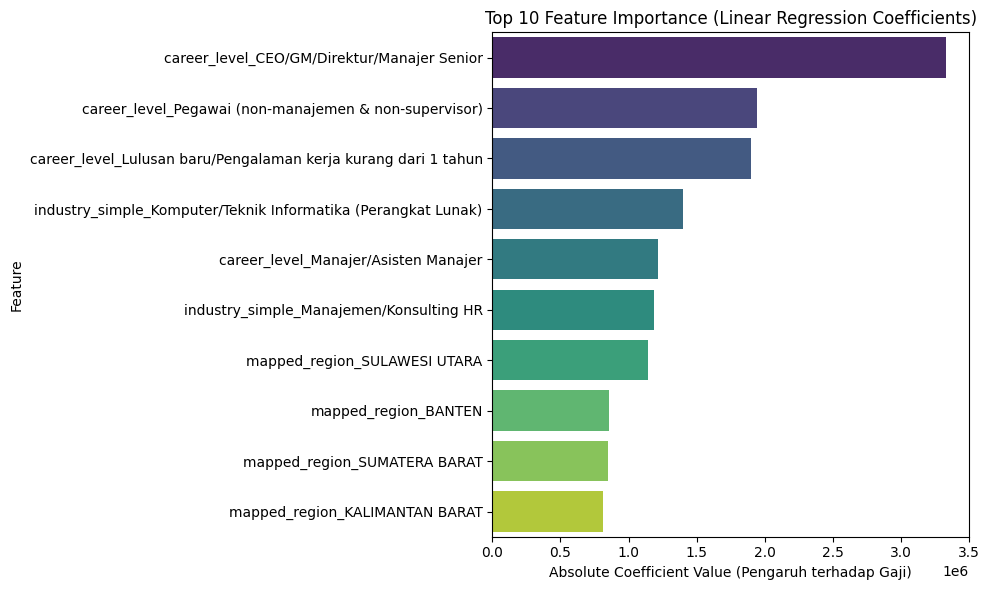

In [10]:
# 1. Ambil encoder dari preprocessor
preprocessor = pipeline.named_steps['preprocessor']

# 2. Ambil nama fitur dari OneHotEncoder (Categorical)
cat_encoder = preprocessor.named_transformers_['cat']
cat_features = list(cat_encoder.get_feature_names_out(['career_level', 'mapped_region', 'industry_simple']))

# 3. Ambil nama fitur dari OrdinalEncoder (Pendidikan & Ukuran Perusahaan)
ord_features = ['edu_simple', 'size_simple']

# 4. Ambil nama fitur Numerical
num_features = ['pengalamanKerja', 'rata2Gaji', 'UMR']

# Gabungkan semua nama fitur sesuai urutan di ColumnTransformer
all_features = num_features + cat_features + ord_features

# 5. Ambil koefisien dari regressor
coefs = pipeline.named_steps['regressor'].coef_

# 6. Buat DataFrame untuk visualisasi
feat_imp = pd.DataFrame({'Feature': all_features, 'Importance': coefs})
feat_imp['Abs_Importance'] = feat_imp['Importance'].abs()

# Sortir berdasarkan nilai absolut terbesar
feat_imp = feat_imp.sort_values(by='Abs_Importance', ascending=False).head(10)

# 7. Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='Abs_Importance', y='Feature', data=feat_imp, palette='viridis')
plt.title('Top 10 Feature Importance (Linear Regression Coefficients)')
plt.xlabel('Absolute Coefficient Value (Pengaruh terhadap Gaji)')
plt.tight_layout()
plt.show()

C:\Users\Albert\AppData\Local\Temp\ipykernel_33364\967798017.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Absolute_Error', y='mapped_region', data=error_by_region, palette='magma')


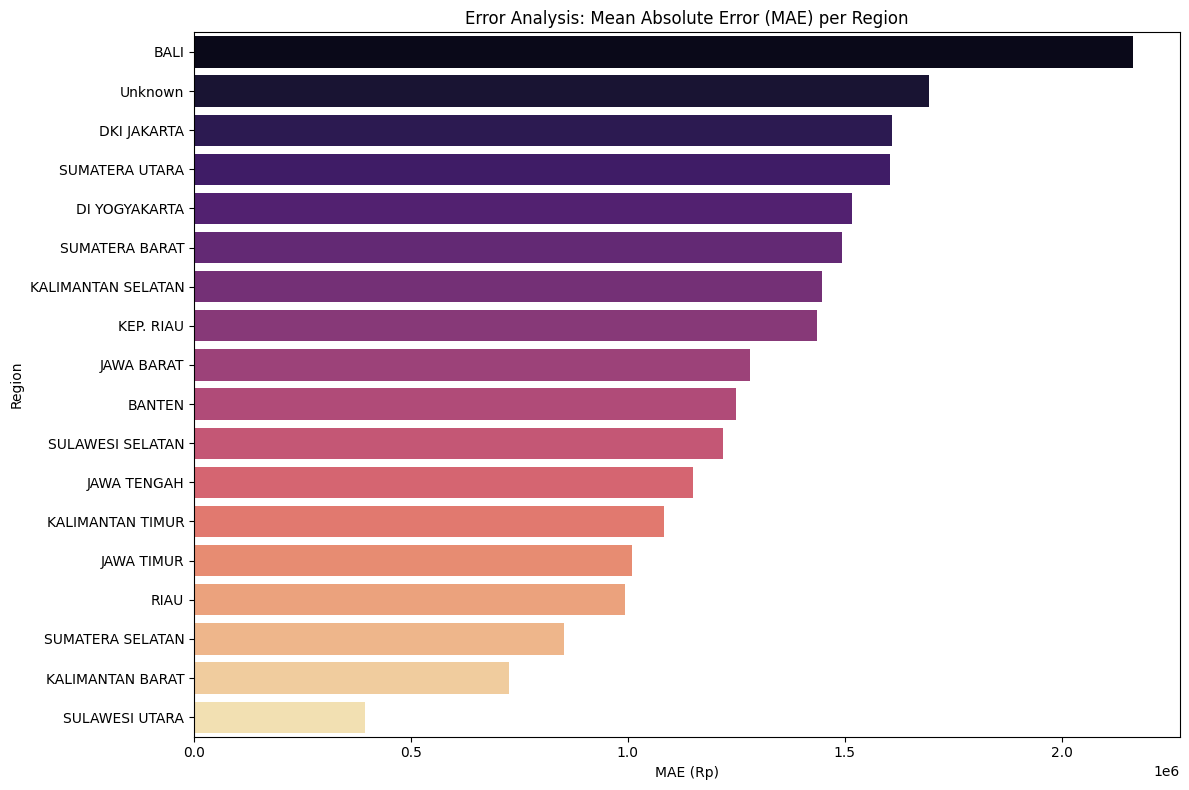

In [11]:

test_results = X_test.copy()
test_results['Actual_Salary'] = y_test
test_results['Predicted_Salary'] = y_pred

test_results['Absolute_Error'] = abs(test_results['Actual_Salary'] - test_results['Predicted_Salary'])


error_by_region = test_results.groupby('mapped_region')['Absolute_Error'].mean().reset_index()
error_by_region = error_by_region.sort_values(by='Absolute_Error', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Absolute_Error', y='mapped_region', data=error_by_region, palette='magma')
plt.title('Error Analysis: Mean Absolute Error (MAE) per Region')
plt.xlabel('MAE (Rp)')
plt.ylabel('Region')
plt.tight_layout()
plt.savefig('error_by_region.png')
plt.show()